<a href="https://colab.research.google.com/github/varshiniwali/UPI-Transaction-Analytics---End-to-End-Project/blob/main/UPI__Transaction_Analyze__Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/UPI Transaction Data.csv')
print(df)

             Transaction_ID Transaction_Date Transaction_Time     UPI_App  \
0       UPI202605P2_0000001       28-05-2026         17:01:47     PhonePe   
1       UPI202605P2_0000002       10-05-2026         12:14:08  Google Pay   
2       UPI202605P2_0000003       04-05-2026         19:43:47       Paytm   
3       UPI202605P2_0000004       14-05-2026         20:05:37     PhonePe   
4       UPI202605P2_0000005       11-05-2026         14:01:05  Amazon Pay   
...                     ...              ...              ...         ...   
263967  UPI202605P2_0263968       21-05-2026         17:41:57     PhonePe   
263968  UPI202605P2_0263969       10-05-2026         20:48:11     PhonePe   
263969  UPI202605P2_0263970       03-05-2026         07:25:33     PhonePe   
263970  UPI202605P2_0263971       01-05-2026         18:08:36  Google Pay   
263971                UPI20              NaN              NaN         NaN   

       Customer_ID Age_Group  Gender           State       City  \
0       

## Data Overview and Cleaning

In [ ]:
# Display basic information about the DataFrame
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263972 entries, 0 to 263971
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Transaction_ID       263972 non-null  object 
 1   Transaction_Date     263971 non-null  object 
 2   Transaction_Time     263971 non-null  object 
 3   UPI_App              263971 non-null  object 
 4   Customer_ID          263971 non-null  object 
 5   Age_Group            263971 non-null  object 
 6   Gender               263971 non-null  object 
 7   State                263971 non-null  object 
 8   City                 263971 non-null  object 
 9   Merchant_Name        263971 non-null  object 
 10  Merchant_Category    263971 non-null  object 
 11  Transaction_Type     263971 non-null  object 
 12  Payment_Mode         263971 non-null  object 
 13  Bank_Name            263971 non-null  object 
 14  Amount_INR           263971 non-null  float64
 15  Cashback_INR     

None

In [ ]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Amount_INR,Cashback_INR,Transaction_Fee_INR,Risk_Score
count,263971.000000,263971.000000,263971.000000,263971.000000
mean,857.369288,6.877177,1.036142,50.551007
std,1226.240714,17.202731,2.111455,28.796110
min,5.620000,0.000000,0.000000,1.000000
25%,242.900000,0.000000,0.000000,26.000000
50%,494.810000,0.000000,0.000000,51.000000
75%,1001.850000,0.000000,0.290000,75.000000
max,60230.340000,75.000000,8.000000,100.000000


## Missing Values Analysis

In [ ]:
# Check for missing values
display(df.isnull().sum())

,0
Transaction_ID,0
Transaction_Date,1
Transaction_Time,1
UPI_App,1
Customer_ID,1
Age_Group,1
Gender,1
State,1
City,1
Merchant_Name,1


In [ ]:
# Calculate the total number of missing values in the entire DataFrame
total_missing_values = df.isnull().sum().sum()

print(f"Total number of missing values in the DataFrame: {total_missing_values}")

Total number of missing values in the DataFrame: 240214


### Revised Strategy for Handling Missing Values

In [ ]:
# Check transactions with Status 'Failed' and NaN in Failure_Reason before imputation
print("Transactions with Status 'Failed' and NaN in Failure_Reason (before imputation):")
display(df[(df['Status'] == 'Failed') & (df['Failure_Reason'].isnull())].head())

Transactions with Status 'Failed' and NaN in Failure_Reason (before imputation):


,Transaction_ID,Transaction_Date,Transaction_Time,UPI_App,Customer_ID,Age_Group,Gender,State,City,Merchant_Name,...,Bank_Name,Amount_INR,Cashback_INR,Transaction_Fee_INR,Status,Failure_Reason,Device_OS,Risk_Score,Is_Suspected_Fraud,Transaction_Day


In [ ]:
# Impute 'Failure_Reason' for successful transactions
df.loc[(df['Status'] == 'Success') & (df['Failure_Reason'].isnull()), 'Failure_Reason'] = 'No Failure'

# Impute 'Failure_Reason' for failed transactions with missing reason
df.loc[(df['Status'] == 'Failed') & (df['Failure_Reason'].isnull()), 'Failure_Reason'] = 'Unknown Failure'

# Verify that there are no more missing values
print("\nMissing values after imputation:")
display(df.isnull().sum())


Missing values after imputation:


,0
Transaction_ID,0
Transaction_Date,1
Transaction_Time,1
UPI_App,1
Customer_ID,1
Age_Group,1
Gender,1
State,1
City,1
Merchant_Name,1


In [ ]:
# Display info and head of the cleaned DataFrame
print("\nDataFrame Info after cleaning:")
display(df.info())

print("\nDataFrame Head after cleaning:")
display(df.head())


DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263972 entries, 0 to 263971
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Transaction_ID       263972 non-null  object        
 1   Transaction_Date     263971 non-null  datetime64[ns]
 2   Transaction_Time     263971 non-null  object        
 3   UPI_App              263971 non-null  object        
 4   Customer_ID          263971 non-null  object        
 5   Age_Group            263971 non-null  object        
 6   Gender               263971 non-null  object        
 7   State                263971 non-null  object        
 8   City                 263971 non-null  object        
 9   Merchant_Name        263971 non-null  object        
 10  Merchant_Category    263971 non-null  object        
 11  Transaction_Type     263971 non-null  object        
 12  Payment_Mode         263971 non-null  ob

None


DataFrame Head after cleaning:


,Transaction_ID,Transaction_Date,Transaction_Time,UPI_App,Customer_ID,Age_Group,Gender,State,City,Merchant_Name,...,Bank_Name,Amount_INR,Cashback_INR,Transaction_Fee_INR,Status,Failure_Reason,Device_OS,Risk_Score,Is_Suspected_Fraud,Transaction_Day
0,UPI202605P2_0000001,2026-05-28,17:01:47,PhonePe,CUST882856,25-34,Male,Telangana,Warangal,Topmate,...,Bank of Baroda,572.53,51.80,0.0,Success,No Failure,iOS,7.0,No,2026-05-28
1,UPI202605P2_0000002,2026-05-10,12:14:08,Google Pay,CUST170502,25-34,Female,Tamil Nadu,Chennai,Udemy,...,Axis Bank,415.75,0.00,0.0,Success,No Failure,Android,72.0,No,2026-05-10
2,UPI202605P2_0000003,2026-05-04,19:43:47,Paytm,CUST107673,35-44,Male,Delhi,New Delhi,Local Clinic,...,Punjab National Bank,1007.05,22.81,0.0,Success,No Failure,Android,29.0,No,2026-05-04
3,UPI202605P2_0000004,2026-05-14,20:05:37,PhonePe,CUST817281,35-44,Female,Telangana,Nizamabad,Indian Oil,...,HDFC Bank,390.86,0.00,0.0,Success,No Failure,Android,93.0,Yes,2026-05-14
4,UPI202605P2_0000005,2026-05-11,14:01:05,Amazon Pay,CUST513285,45-54,Female,Gujarat,Surat,Data Tutorials,...,Punjab National Bank,165.15,15.37,0.0,Success,No Failure,iOS,25.0,No,2026-05-11


### Final Imputation of Remaining Missing Values
Handling the last row with pervasive `NaN`s by filling with 'Unknown' for categorical and `0` for numerical columns.

In [ ]:
# Identify columns by type
object_cols = df.select_dtypes(include='object').columns
float_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Fill remaining NaN values
# For object columns, fill with 'Unknown'
for col in object_cols:
    df[col].fillna('Unknown', inplace=True)

# For numerical columns, fill with 0
for col in float_cols:
    df[col].fillna(0, inplace=True)

# For datetime column (Transaction_Date), fill with a default valid date
# '1970-01-01' is a common placeholder for unknown dates
if pd.api.types.is_datetime64_any_dtype(df['Transaction_Date']):
    df['Transaction_Date'] = df['Transaction_Date'].fillna(pd.to_datetime('1970-01-01'))
    # Also handle Transaction_Day, which is derived from Transaction_Date and is currently an object type
    df['Transaction_Day'] = df['Transaction_Day'].fillna('1970-01-01') # Filling as string as its dtype is object

# Verify no more missing values
print("\nMissing values after final imputation:")
display(df.isnull().sum())

/tmp/ipykernel_1164/948770168.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)
/tmp/ipykernel_1164/948770168.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.


Missing values after final imputation:


,0
Transaction_ID,0
Transaction_Date,0
Transaction_Time,0
UPI_App,0
Customer_ID,0
Age_Group,0
Gender,0
State,0
City,0
Merchant_Name,0


In [ ]:
# Display info and head of the fully cleaned DataFrame
print("\nDataFrame Info after final cleaning:")
display(df.info())

print("\nDataFrame Head after final cleaning:")
display(df.head())


DataFrame Info after final cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263972 entries, 0 to 263971
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Transaction_ID       263972 non-null  object        
 1   Transaction_Date     263972 non-null  datetime64[ns]
 2   Transaction_Time     263972 non-null  object        
 3   UPI_App              263972 non-null  object        
 4   Customer_ID          263972 non-null  object        
 5   Age_Group            263972 non-null  object        
 6   Gender               263972 non-null  object        
 7   State                263972 non-null  object        
 8   City                 263972 non-null  object        
 9   Merchant_Name        263972 non-null  object        
 10  Merchant_Category    263972 non-null  object        
 11  Transaction_Type     263972 non-null  object        
 12  Payment_Mode         263972 non-nu

None


DataFrame Head after final cleaning:


,Transaction_ID,Transaction_Date,Transaction_Time,UPI_App,Customer_ID,Age_Group,Gender,State,City,Merchant_Name,...,Bank_Name,Amount_INR,Cashback_INR,Transaction_Fee_INR,Status,Failure_Reason,Device_OS,Risk_Score,Is_Suspected_Fraud,Transaction_Day
0,UPI202605P2_0000001,2026-05-28,17:01:47,PhonePe,CUST882856,25-34,Male,Telangana,Warangal,Topmate,...,Bank of Baroda,572.53,51.80,0.0,Success,No Failure,iOS,7.0,No,2026-05-28
1,UPI202605P2_0000002,2026-05-10,12:14:08,Google Pay,CUST170502,25-34,Female,Tamil Nadu,Chennai,Udemy,...,Axis Bank,415.75,0.00,0.0,Success,No Failure,Android,72.0,No,2026-05-10
2,UPI202605P2_0000003,2026-05-04,19:43:47,Paytm,CUST107673,35-44,Male,Delhi,New Delhi,Local Clinic,...,Punjab National Bank,1007.05,22.81,0.0,Success,No Failure,Android,29.0,No,2026-05-04
3,UPI202605P2_0000004,2026-05-14,20:05:37,PhonePe,CUST817281,35-44,Female,Telangana,Nizamabad,Indian Oil,...,HDFC Bank,390.86,0.00,0.0,Success,No Failure,Android,93.0,Yes,2026-05-14
4,UPI202605P2_0000005,2026-05-11,14:01:05,Amazon Pay,CUST513285,45-54,Female,Gujarat,Surat,Data Tutorials,...,Punjab National Bank,165.15,15.37,0.0,Success,No Failure,iOS,25.0,No,2026-05-11


In [ ]:
# Convert 'Transaction_Date' to datetime objects, coercing errors to NaT
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], format='%d-%m-%Y', errors='coerce')

# Convert 'Transaction_Time' to datetime.time objects for easier manipulation
df['Transaction_Time'] = pd.to_datetime(df['Transaction_Time'], format='%H:%M:%S', errors='coerce').dt.time

# Convert numerical columns to appropriate types
# Using to_numeric with errors='coerce' to handle potential non-numeric entries gracefully
df['Amount_INR'] = pd.to_numeric(df['Amount_INR'], errors='coerce')
df['Cashback_INR'] = pd.to_numeric(df['Cashback_INR'], errors='coerce')
df['Transaction_Fee_INR'] = pd.to_numeric(df['Transaction_Fee_INR'], errors='coerce')
df['Risk_Score'] = pd.to_numeric(df['Risk_Score'], errors='coerce')

# Display info again after cleaning and type conversion
display(df.info())

# Display the first few rows of the cleaned DataFrame
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263972 entries, 0 to 263971
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Transaction_ID       263972 non-null  object        
 1   Transaction_Date     263972 non-null  datetime64[ns]
 2   Transaction_Time     263971 non-null  object        
 3   UPI_App              263972 non-null  object        
 4   Customer_ID          263972 non-null  object        
 5   Age_Group            263972 non-null  object        
 6   Gender               263972 non-null  object        
 7   State                263972 non-null  object        
 8   City                 263972 non-null  object        
 9   Merchant_Name        263972 non-null  object        
 10  Merchant_Category    263972 non-null  object        
 11  Transaction_Type     263972 non-null  object        
 12  Payment_Mode         263972 non-null  object        
 13  Bank_Name     

None

,Transaction_ID,Transaction_Date,Transaction_Time,UPI_App,Customer_ID,Age_Group,Gender,State,City,Merchant_Name,...,Bank_Name,Amount_INR,Cashback_INR,Transaction_Fee_INR,Status,Failure_Reason,Device_OS,Risk_Score,Is_Suspected_Fraud,Transaction_Day
0,UPI202605P2_0000001,2026-05-28,17:01:47,PhonePe,CUST882856,25-34,Male,Telangana,Warangal,Topmate,...,Bank of Baroda,572.53,51.80,0.0,Success,No Failure,iOS,7.0,No,2026-05-28
1,UPI202605P2_0000002,2026-05-10,12:14:08,Google Pay,CUST170502,25-34,Female,Tamil Nadu,Chennai,Udemy,...,Axis Bank,415.75,0.00,0.0,Success,No Failure,Android,72.0,No,2026-05-10
2,UPI202605P2_0000003,2026-05-04,19:43:47,Paytm,CUST107673,35-44,Male,Delhi,New Delhi,Local Clinic,...,Punjab National Bank,1007.05,22.81,0.0,Success,No Failure,Android,29.0,No,2026-05-04
3,UPI202605P2_0000004,2026-05-14,20:05:37,PhonePe,CUST817281,35-44,Female,Telangana,Nizamabad,Indian Oil,...,HDFC Bank,390.86,0.00,0.0,Success,No Failure,Android,93.0,Yes,2026-05-14
4,UPI202605P2_0000005,2026-05-11,14:01:05,Amazon Pay,CUST513285,45-54,Female,Gujarat,Surat,Data Tutorials,...,Punjab National Bank,165.15,15.37,0.0,Success,No Failure,iOS,25.0,No,2026-05-11


## Data Visualization: Distributions of Categorical Variables

/tmp/ipykernel_1164/829751154.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='UPI_App', data=df, order=df['UPI_App'].value_counts().index, palette='viridis')


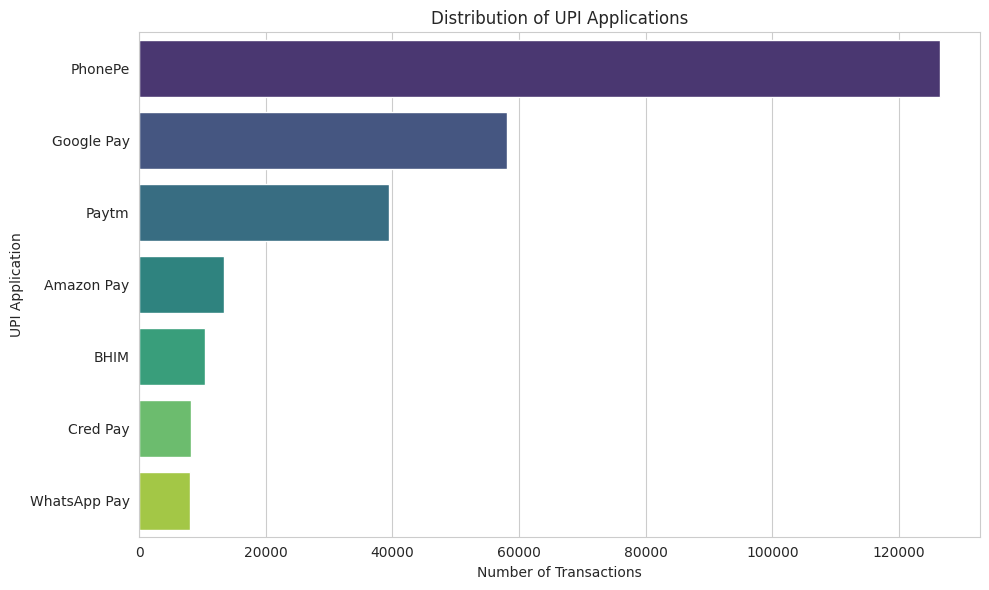

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots for better aesthetics
sns.set_style("whitegrid")

# Plot distribution of UPI Apps
plt.figure(figsize=(10, 6))
sns.countplot(y='UPI_App', data=df, order=df['UPI_App'].value_counts().index, palette='viridis')
plt.title('Distribution of UPI Applications')
plt.xlabel('Number of Transactions')
plt.ylabel('UPI Application')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1164/1808727453.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status', data=df, palette='magma')


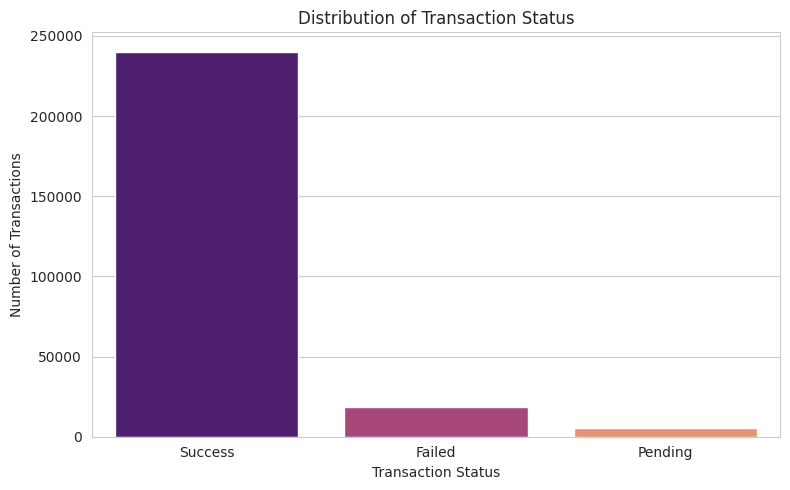

In [ ]:
# Plot distribution of Transaction Status
plt.figure(figsize=(8, 5))
sns.countplot(x='Status', data=df, palette='magma')
plt.title('Distribution of Transaction Status')
plt.xlabel('Transaction Status')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1164/1252690481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Is_Suspected_Fraud', data=df, palette='cividis')


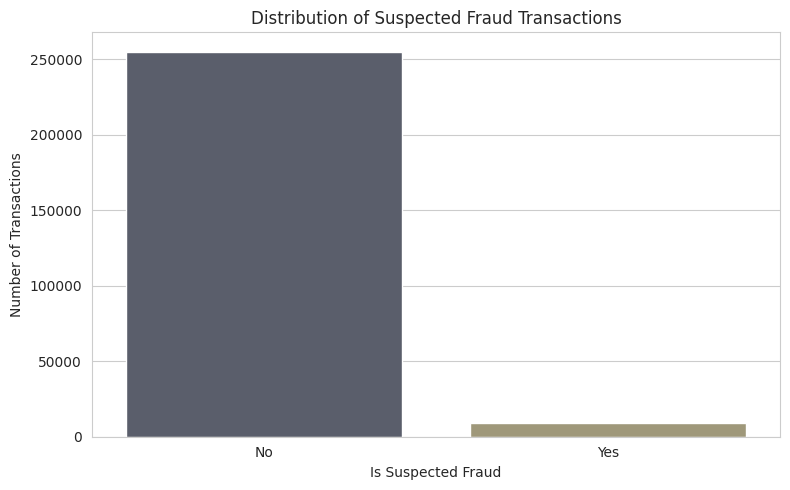

In [ ]:
# Plot distribution of Is_Suspected_Fraud
plt.figure(figsize=(8, 5))
sns.countplot(x='Is_Suspected_Fraud', data=df, palette='cividis')
plt.title('Distribution of Suspected Fraud Transactions')
plt.xlabel('Is Suspected Fraud')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

## Data Visualization: Distributions of Numerical Variables

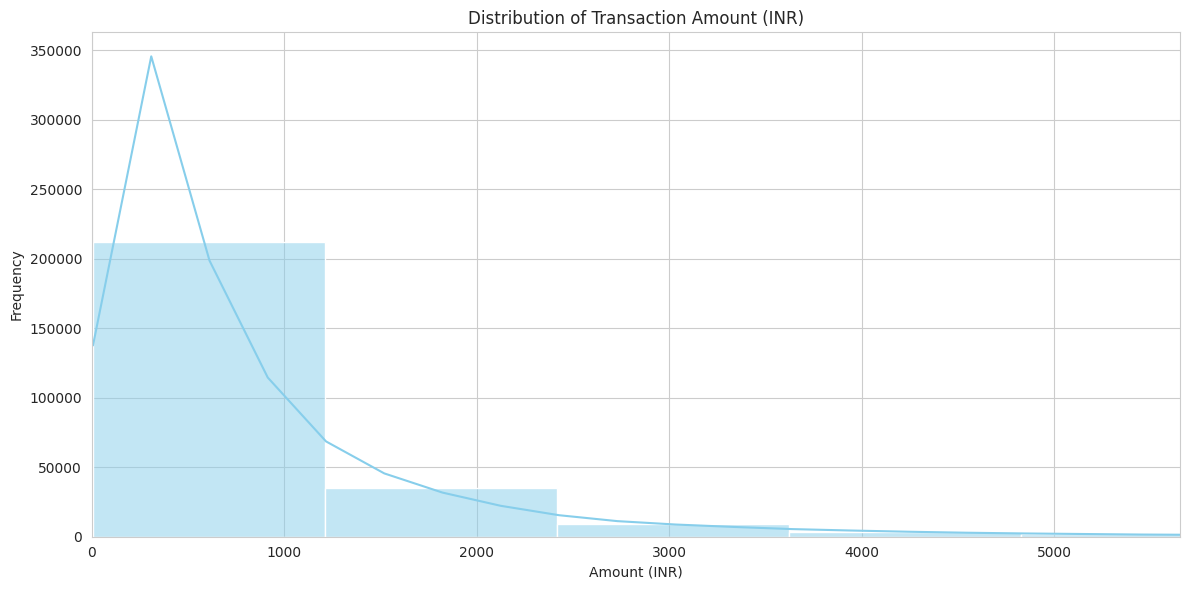

In [ ]:
# Plot histogram for Amount_INR
plt.figure(figsize=(12, 6))
sns.histplot(df['Amount_INR'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Transaction Amount (INR)')
plt.xlabel('Amount (INR)')
plt.ylabel('Frequency')
plt.xlim(0, df['Amount_INR'].quantile(0.99)) # Limit x-axis to better visualize the main distribution
plt.tight_layout()
plt.show()

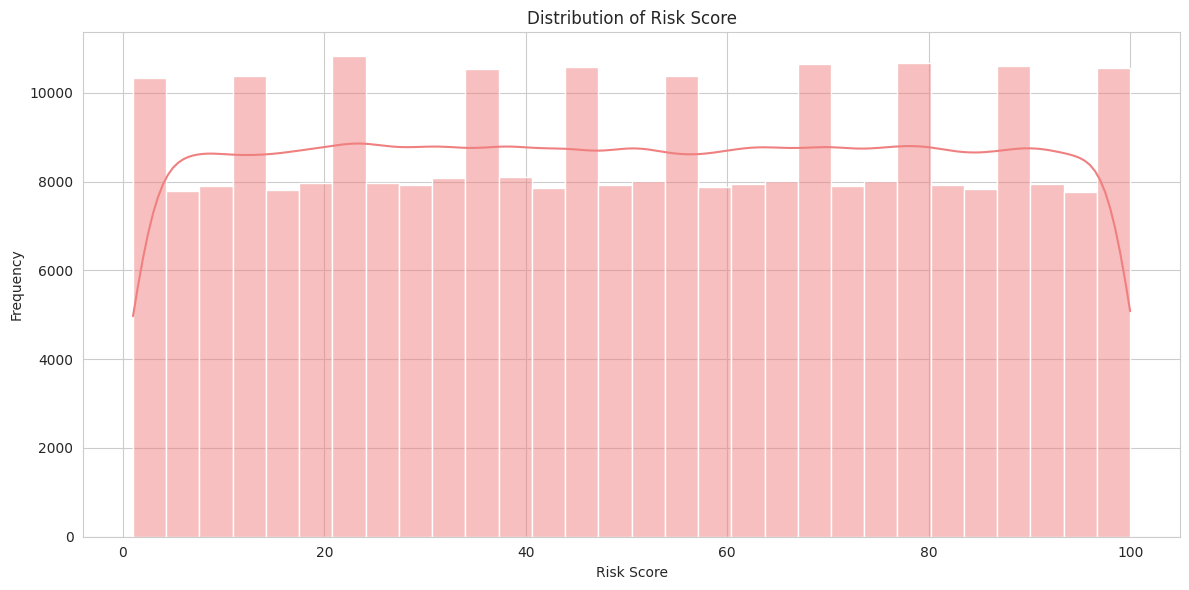

In [ ]:
# Plot histogram for Risk_Score
plt.figure(figsize=(12, 6))
sns.histplot(df['Risk_Score'], bins=30, kde=True, color='lightcoral')
plt.title('Distribution of Risk Score')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Data Visualization: Relationships and Time Series

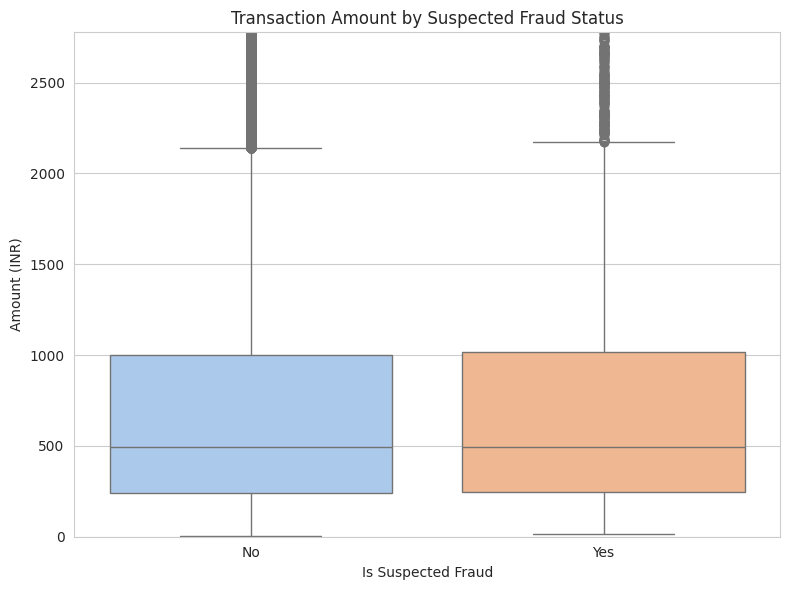

In [ ]:
# Box plot of Amount_INR by Is_Suspected_Fraud
plt.figure(figsize=(8, 6))
sns.boxplot(x='Is_Suspected_Fraud', y='Amount_INR', data=df, palette='pastel', hue='Is_Suspected_Fraud', legend=False)
plt.title('Transaction Amount by Suspected Fraud Status')
plt.xlabel('Is Suspected Fraud')
plt.ylabel('Amount (INR)')
plt.ylim(0, df['Amount_INR'].quantile(0.95)) # Limit y-axis for better visualization
plt.tight_layout()
plt.show()

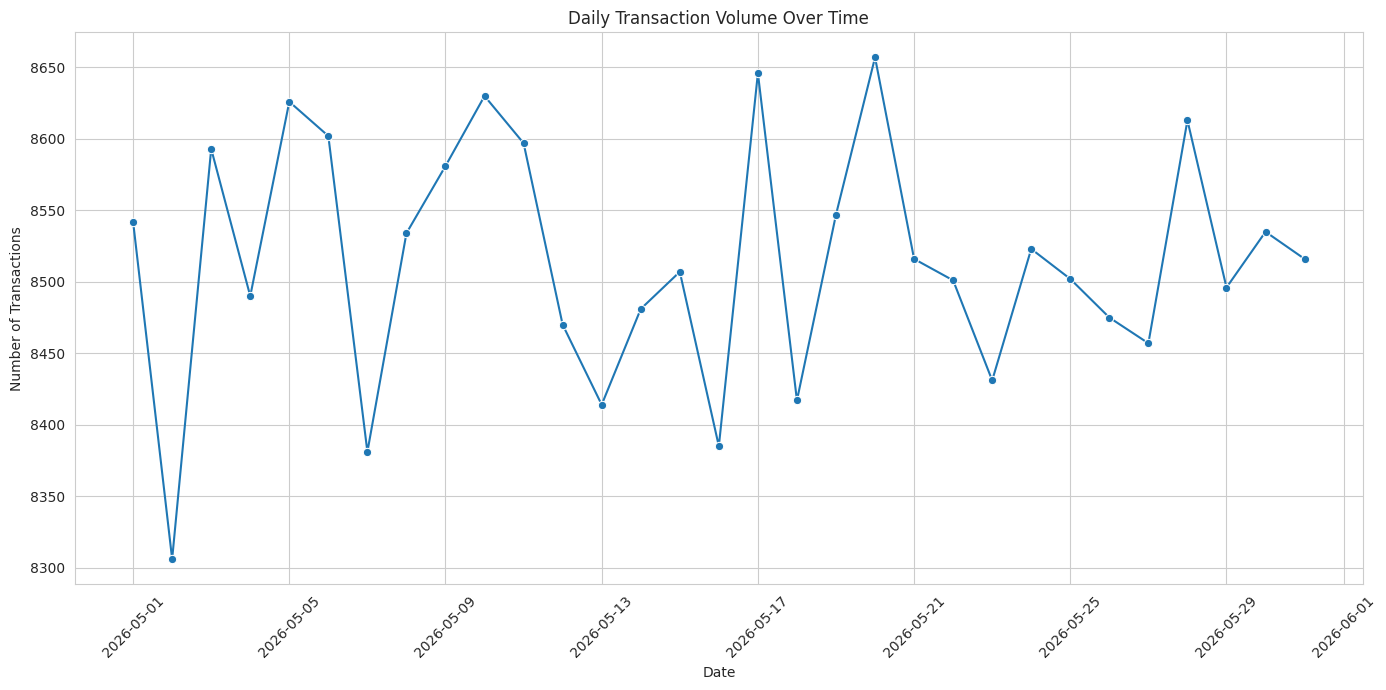

In [ ]:
# Create 'Transaction_Day' for daily analysis
df['Transaction_Day'] = df['Transaction_Date'].dt.date

# Daily Transaction Volume over Time
daily_volume = df.groupby('Transaction_Day').size().reset_index(name='Transaction_Count')

plt.figure(figsize=(14, 7))
sns.lineplot(x='Transaction_Day', y='Transaction_Count', data=daily_volume, marker='o')
plt.title('Daily Transaction Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

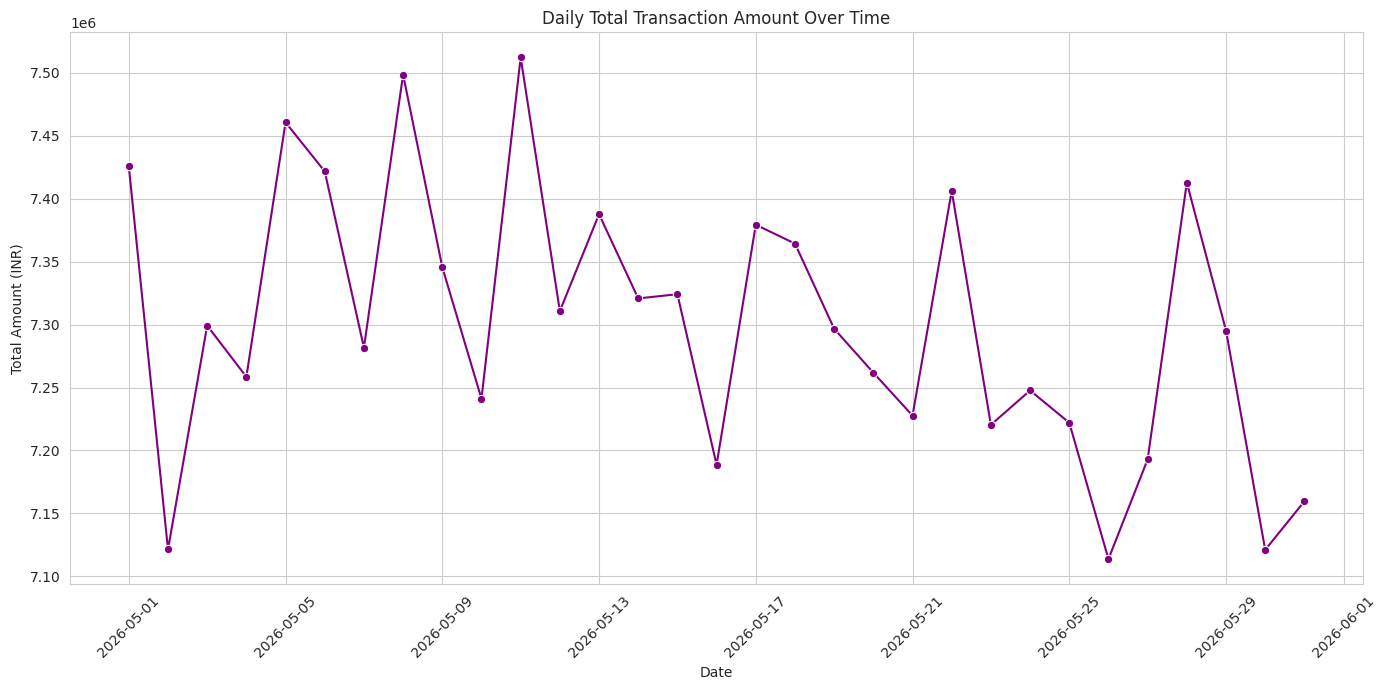

In [ ]:
# Daily Total Amount over Time
daily_amount = df.groupby('Transaction_Day')['Amount_INR'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='Transaction_Day', y='Amount_INR', data=daily_amount, marker='o', color='purple')
plt.title('Daily Total Transaction Amount Over Time')
plt.xlabel('Date')
plt.ylabel('Total Amount (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Fraud Analysis by Device OS

In [ ]:
# Calculate total transactions per Device_OS
total_transactions_by_device = df.groupby('Device_OS').size().reset_index(name='Total_Transactions')

# Calculate fraudulent transactions per Device_OS
fraud_transactions_by_device = df[df['Is_Suspected_Fraud'] == 'Yes'].groupby('Device_OS').size().reset_index(name='Fraud_Transactions')

# Merge the two dataframes
fraud_analysis = pd.merge(total_transactions_by_device, fraud_transactions_by_device, on='Device_OS', how='left')

# Fill NaN fraud transactions with 0 (for devices with no fraud)
fraud_analysis['Fraud_Transactions'] = fraud_analysis['Fraud_Transactions'].fillna(0).astype(int)

# Calculate percentage of fraud
fraud_analysis['Fraud_Percentage'] = (fraud_analysis['Fraud_Transactions'] / fraud_analysis['Total_Transactions']) * 100

# Display the results
display(fraud_analysis.sort_values(by='Fraud_Percentage', ascending=False))

,Device_OS,Total_Transactions,Fraud_Transactions,Fraud_Percentage
1,iOS,47741,1628,3.410067
0,Android,216230,7282,3.367710


/tmp/ipykernel_1164/2263742992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Device_OS', y='Fraud_Percentage', data=fraud_analysis, palette='rocket')


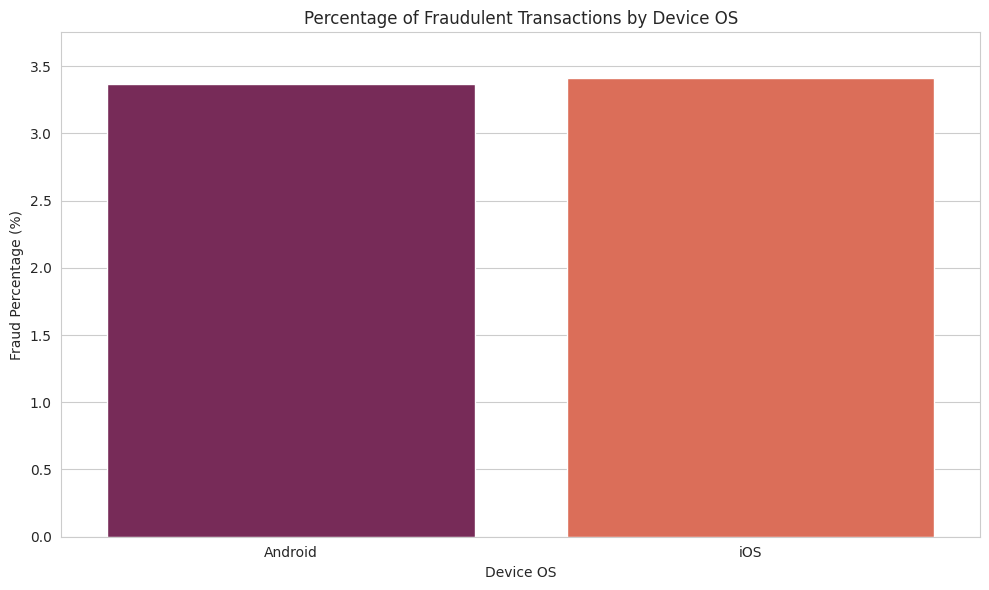

In [ ]:
# Visualize the Fraud Percentage by Device OS
plt.figure(figsize=(10, 6))
sns.barplot(x='Device_OS', y='Fraud_Percentage', data=fraud_analysis, palette='rocket')
plt.title('Percentage of Fraudulent Transactions by Device OS')
plt.xlabel('Device OS')
plt.ylabel('Fraud Percentage (%)')
plt.ylim(0, fraud_analysis['Fraud_Percentage'].max() * 1.1)
plt.tight_layout()
plt.show()

## Fraud Analysis by UPI Application

In [ ]:
# Calculate total transactions per UPI_App
total_transactions_by_app = df.groupby('UPI_App').size().reset_index(name='Total_Transactions')

# Calculate fraudulent transactions per UPI_App
fraud_transactions_by_app = df[df['Is_Suspected_Fraud'] == 'Yes'].groupby('UPI_App').size().reset_index(name='Fraud_Transactions')

# Merge the two dataframes
fraud_app_analysis = pd.merge(total_transactions_by_app, fraud_transactions_by_app, on='UPI_App', how='left')

# Fill NaN fraud transactions with 0 (for apps with no fraud)
fraud_app_analysis['Fraud_Transactions'] = fraud_app_analysis['Fraud_Transactions'].fillna(0).astype(int)

# Calculate percentage of fraud
fraud_app_analysis['Fraud_Percentage'] = (fraud_app_analysis['Fraud_Transactions'] / fraud_app_analysis['Total_Transactions']) * 100

# Display the results
display(fraud_app_analysis.sort_values(by='Fraud_Percentage', ascending=False))

,UPI_App,Total_Transactions,Fraud_Transactions,Fraud_Percentage
2,Cred Pay,8121,301,3.706440
3,Google Pay,58112,2011,3.460559
5,PhonePe,126489,4280,3.383693
0,Amazon Pay,13355,451,3.377012
1,BHIM,10448,348,3.330781
6,WhatsApp Pay,8004,263,3.285857
4,Paytm,39442,1256,3.184423


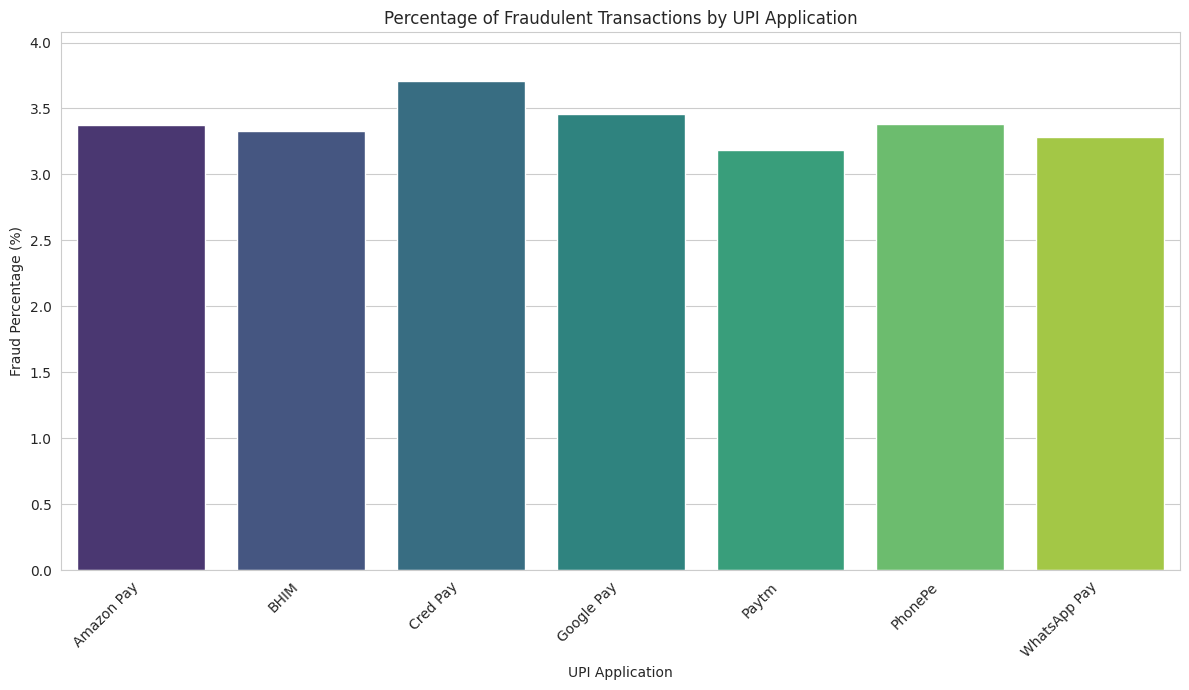

In [ ]:
# Visualize the Fraud Percentage by UPI Application
plt.figure(figsize=(12, 7))
sns.barplot(x='UPI_App', y='Fraud_Percentage', data=fraud_app_analysis, palette='viridis', hue='UPI_App', legend=False)
plt.title('Percentage of Fraudulent Transactions by UPI Application')
plt.xlabel('UPI Application')
plt.ylabel('Fraud Percentage (%)')
plt.ylim(0, fraud_app_analysis['Fraud_Percentage'].max() * 1.1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Correlation Analysis: Risk Score vs. Transaction Amount

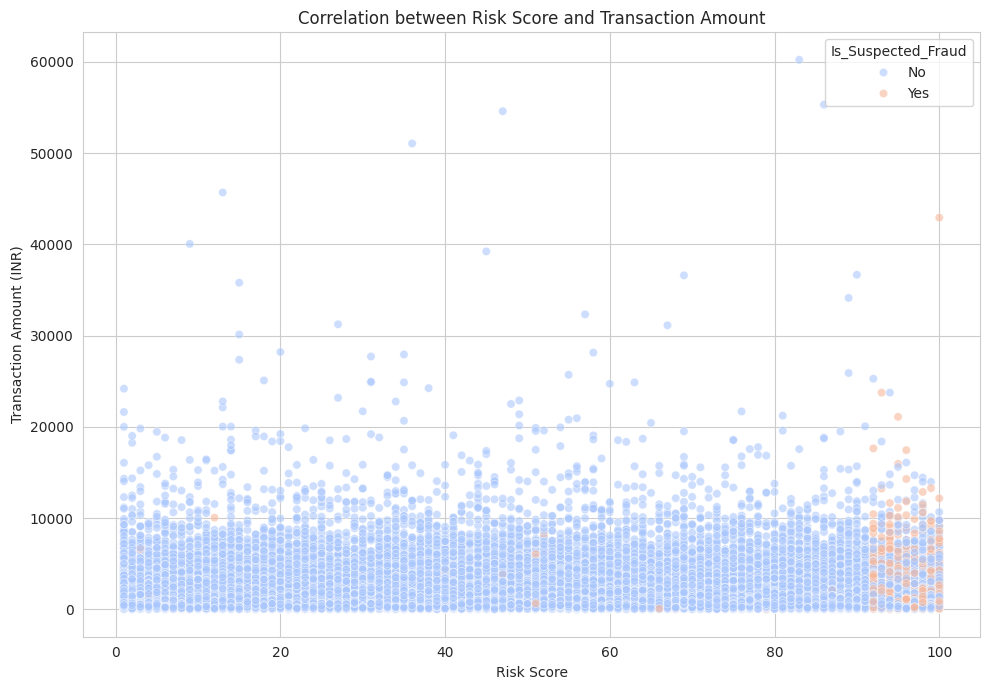

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Risk_Score', y='Amount_INR', data=df, hue='Is_Suspected_Fraud', palette='coolwarm', alpha=0.6)
plt.title('Correlation between Risk Score and Transaction Amount')
plt.xlabel('Risk Score')
plt.ylabel('Transaction Amount (INR)')
plt.tight_layout()
plt.show()

## Visualize Correlations: Heatmap

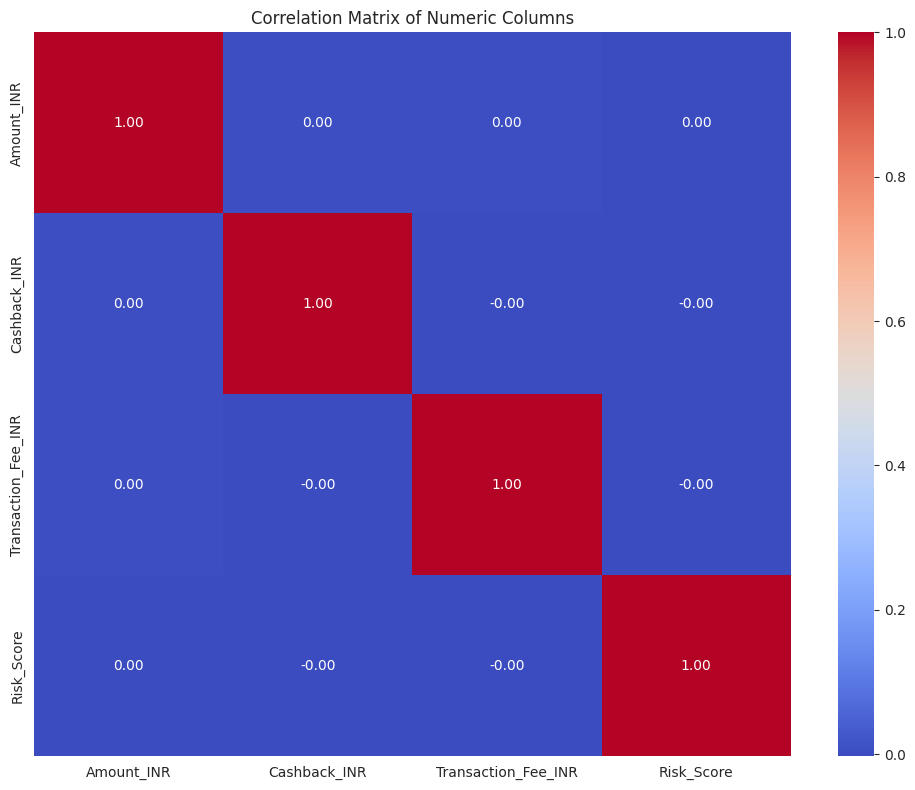

In [ ]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Columns')
plt.tight_layout()
plt.show()